In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [191]:
df = pd.read_excel("Oil_Gas_Predictive_Maintenance.xlsx")
df.head(10)

,timestamp,equipment_id,equipment_type,temperature_C,pressure_bar,vibration_mm_s,flow_rate_m3_h,motor_current_A,oil_level_pct,runtime_hours,ambient_temp_C,humidity_pct,maintenance_days,previous_failures,failure
0,2026-01-01T00:00:00,EQ-1013,Compressor,72.30,35.99,0.34,101.47,81.06,51.1,469,23.74,50.0,130.0,0,0
1,2026-01-01T01:00:00,EQ-1041,Turbine,83.42,42.76,4.34,115.42,73.35,60.5,14489,32.62,34.7,113.0,4,0
2,2026-01-01T02:00:00,EQ-1042,Turbine,67.78,31.36,3.15,114.99,105.03,59.3,8707,29.54,84.0,46.0,1,0
3,2026-01-01T03:00:00,EQ-1044,Pump,79.91,43.29,2.60,108.37,76.36,NaN,2490,39.49,85.4,358.0,5,1
4,2026-01-01T04:00:00,EQ-1026,Turbine,66.82,28.97,2.81,116.51,115.56,72.7,12814,27.28,85.2,23.0,4,0
5,2026-01-01T05:00:00,EQ-1032,Turbine,80.28,51.96,3.25,141.61,70.60,NaN,5943,29.38,52.9,137.0,2,0
6,2026-01-01T06:00:00,EQ-1012,Turbine,80.36,43.98,2.01,121.99,69.58,66.5,3942,23.92,41.0,NaN,4,0
7,2026-01-01T07:00:00,EQ-1023,Turbine,71.49,41.53,3.00,90.23,123.16,81.8,18590,29.93,45.3,111.0,1,0
8,2026-01-01T08:00:00,EQ-1022,Valve,63.10,46.15,3.34,125.04,84.60,100.0,17639,28.51,35.3,137.0,4,0
9,2026-01-01T09:00:00,EQ-1004,Valve,59.84,40.87,0.88,89.52,108.21,43.4,5033,36.09,48.2,267.0,4,0


In [192]:
# dataset shape
df.shape   # 5025 rows, 15 cols

(5025, 15)

In [193]:
# dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5025 entries, 0 to 5024
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          5025 non-null   str    
 1   equipment_id       5025 non-null   str    
 2   equipment_type     5025 non-null   str    
 3   temperature_C      4757 non-null   float64
 4   pressure_bar       4707 non-null   float64
 5   vibration_mm_s     4729 non-null   float64
 6   flow_rate_m3_h     4703 non-null   float64
 7   motor_current_A    4713 non-null   float64
 8   oil_level_pct      4725 non-null   float64
 9   runtime_hours      5025 non-null   int64  
 10  ambient_temp_C     4721 non-null   float64
 11  humidity_pct       4732 non-null   float64
 12  maintenance_days   4733 non-null   float64
 13  previous_failures  5025 non-null   int64  
 14  failure            5025 non-null   int64  
dtypes: float64(9), int64(3), str(3)
memory usage: 589.0 KB


In [194]:
# dataset statistical summary

df.describe()

,temperature_C,pressure_bar,vibration_mm_s,flow_rate_m3_h,motor_current_A,oil_level_pct,runtime_hours,ambient_temp_C,humidity_pct,maintenance_days,previous_failures,failure
count,4757.000000,4707.000000,4729.000000,4703.000000,4713.000000,4725.000000,5025.000000,4721.000000,4732.000000,4733.000000,5025.000000,5025.000000
mean,75.491859,40.005341,3.050592,120.340563,89.858311,69.826899,10049.464677,30.869407,56.770731,183.707374,2.516816,0.058308
std,10.998883,7.065598,1.357572,18.153709,13.922307,16.903099,5783.989740,4.954669,18.831787,107.152611,1.716051,0.234349
min,41.640000,15.540000,0.300000,50.320000,40.390000,5.000000,112.000000,14.820000,25.000000,0.000000,0.000000,0.000000
25%,68.530000,35.270000,2.220000,108.050000,80.390000,57.900000,4979.000000,27.590000,40.700000,91.000000,1.000000,0.000000
50%,75.190000,39.990000,2.980000,120.230000,89.670000,70.200000,10040.000000,30.860000,55.850000,183.000000,3.000000,0.000000
75%,82.060000,44.725000,3.740000,132.855000,99.700000,81.900000,15121.000000,34.280000,73.000000,278.000000,4.000000,0.000000
max,149.470034,66.110000,14.878473,179.020000,145.440000,100.000000,19997.000000,46.450000,90.000000,365.000000,5.000000,1.000000


In [195]:
# check missing values
df.isnull().sum()

timestamp              0
equipment_id           0
equipment_type         0
temperature_C        268
pressure_bar         318
vibration_mm_s       296
flow_rate_m3_h       322
motor_current_A      312
oil_level_pct        300
runtime_hours          0
ambient_temp_C       304
humidity_pct         293
maintenance_days     292
previous_failures      0
failure                0
dtype: int64

In [196]:
# check missing values percentage

(df.isnull().sum() / len(df)) * 100

timestamp            0.000000
equipment_id         0.000000
equipment_type       0.000000
temperature_C        5.333333
pressure_bar         6.328358
vibration_mm_s       5.890547
flow_rate_m3_h       6.407960
motor_current_A      6.208955
oil_level_pct        5.970149
runtime_hours        0.000000
ambient_temp_C       6.049751
humidity_pct         5.830846
maintenance_days     5.810945
previous_failures    0.000000
failure              0.000000
dtype: float64

In [197]:
# checking duplicated values

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 25


In [198]:
# checking datatypes

df.dtypes

timestamp                str
equipment_id             str
equipment_type           str
temperature_C        float64
pressure_bar         float64
vibration_mm_s       float64
flow_rate_m3_h       float64
motor_current_A      float64
oil_level_pct        float64
runtime_hours          int64
ambient_temp_C       float64
humidity_pct         float64
maintenance_days     float64
previous_failures      int64
failure                int64
dtype: object

In [199]:
# checking unique values

df.nunique()

timestamp            5000
equipment_id           50
equipment_type          4
temperature_C        2741
pressure_bar         2266
vibration_mm_s        562
flow_rate_m3_h       3350
motor_current_A      3077
oil_level_pct         710
runtime_hours        4421
ambient_temp_C       1809
humidity_pct          650
maintenance_days      366
previous_failures       6
failure                 2
dtype: int64

In [200]:
# checking if data is imbalanced or not

df["failure"].value_counts()

failure
0    4732
1     293
Name: count, dtype: int64

In [201]:
# checking imbalanced data percentage

(df["failure"].value_counts(normalize=True) * 100).round(2)

failure
0    94.17
1     5.83
Name: proportion, dtype: float64

#### The target variable is highly imbalanced with approximately 94% normal observations and 6% failure cases. This reflects real-world predictive maintenance scenarios, where failures occur infrequently.

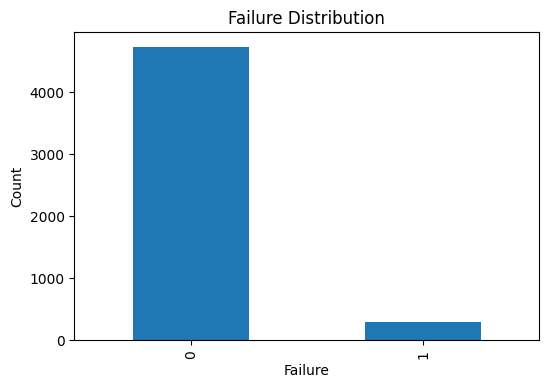

In [202]:
# plotting failure count

plt.figure(figsize=(6,4))

df["failure"].value_counts().plot(kind="bar")

plt.title("Failure Distribution")
plt.xlabel("Failure")
plt.ylabel("Count")

plt.show()

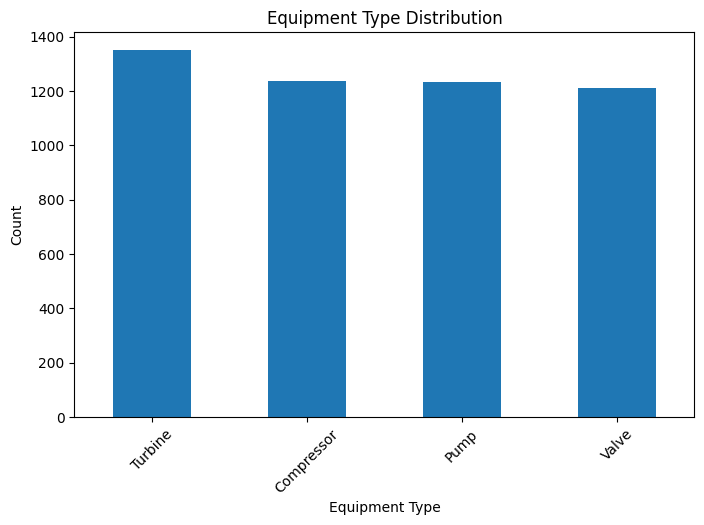

In [203]:
# equipment distribution plot

plt.figure(figsize=(8,5))

df["equipment_type"].value_counts().plot(kind="bar")

plt.title("Equipment Type Distribution")
plt.xlabel("Equipment Type")
plt.ylabel("Count")

plt.xticks(rotation=45)

plt.show()

### Equipment Distribution Plot:

#### This analysis shows the number of records for each equipment type in the dataset. It helps determine whether the dataset is balanced across different equipment categories and provides insight into the operational assets being analyzed.

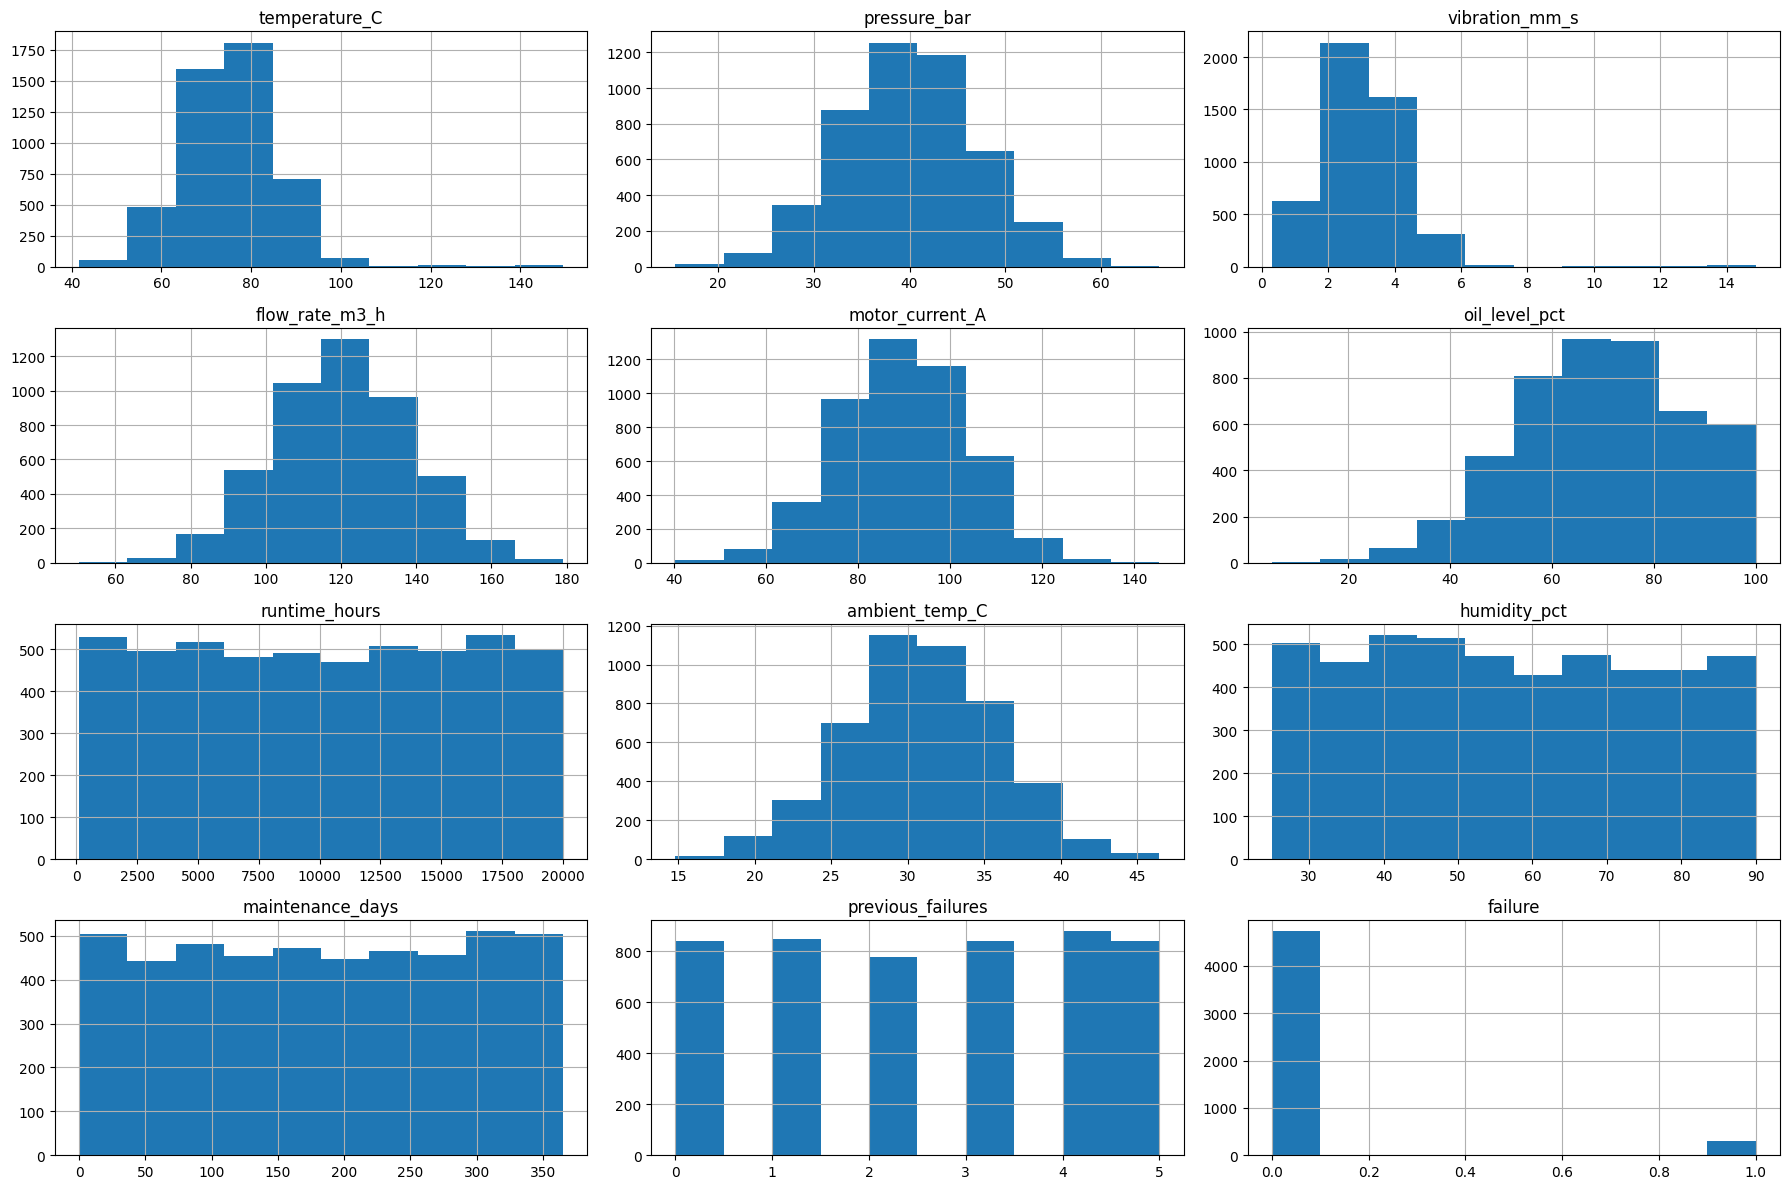

In [204]:
# numerical feature distribution

df.hist(figsize=(18,12))

plt.tight_layout()

plt.show()

### Numerical Feature Distribution

#### Histograms are used to visualize the distribution of numerical features. This helps identify the range, spread, skewness, and potential outliers in the sensor data, which is essential for effective feature engineering and model development.

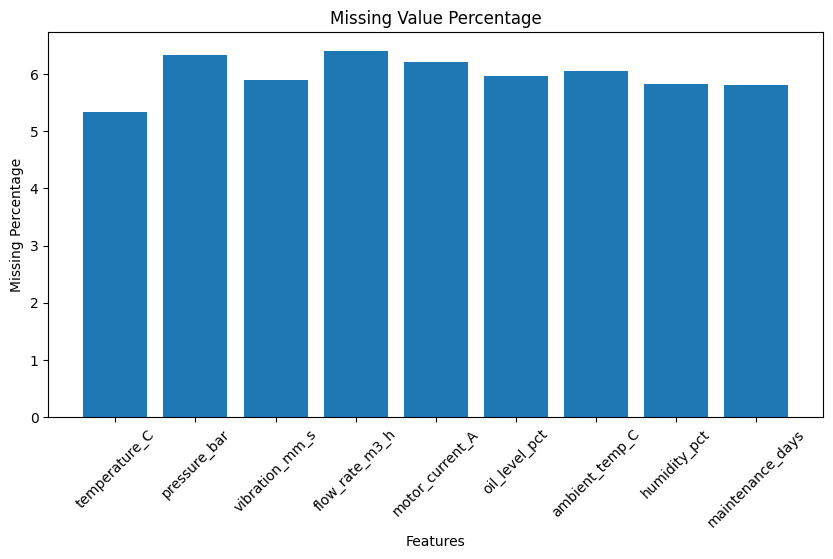

In [205]:
# visualization missing values

missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_percentage = missing_percentage[missing_percentage > 0]

plt.figure(figsize=(10,5))

plt.bar(missing_percentage.index,
        missing_percentage.values)

plt.title("Missing Value Percentage")
plt.xlabel("Features")
plt.ylabel("Missing Percentage")

plt.xticks(rotation=45)

plt.show()

## Observation

#### The missing value analysis indicates that approximately 5–6% of values are missing across multiple numerical sensor features. Since the percentage of missing values is relatively low, these features will be retained and the missing values will be handled during the feature engineering stage using appropriate imputation techniques.

In [206]:
# correlation matrix

correlation = df.corr(numeric_only=True)

correlation

,temperature_C,pressure_bar,vibration_mm_s,flow_rate_m3_h,motor_current_A,oil_level_pct,runtime_hours,ambient_temp_C,humidity_pct,maintenance_days,previous_failures,failure
temperature_C,1.000000,0.011024,0.272802,-0.000505,0.003174,-0.015685,0.024293,-0.014481,0.018285,-0.001328,0.007052,0.149841
pressure_bar,0.011024,1.000000,0.000292,0.011891,-0.021881,-0.018297,0.027313,0.009012,-0.020650,0.015643,-0.001159,0.026356
vibration_mm_s,0.272802,0.000292,1.000000,-0.016804,0.009522,0.001331,-0.014714,0.023060,0.020175,0.033807,0.014035,0.022297
flow_rate_m3_h,-0.000505,0.011891,-0.016804,1.000000,0.020643,0.002241,0.016153,-0.020595,-0.020959,0.009047,-0.013943,-0.006087
motor_current_A,0.003174,-0.021881,0.009522,0.020643,1.000000,0.004774,-0.003591,0.010357,-0.029941,0.000872,0.009904,-0.010185
oil_level_pct,-0.015685,-0.018297,0.001331,0.002241,0.004774,1.000000,-0.007525,-0.011872,0.009260,0.000757,-0.008307,-0.039943
runtime_hours,0.024293,0.027313,-0.014714,0.016153,-0.003591,-0.007525,1.000000,0.002348,0.026068,0.010368,0.001673,0.062888
ambient_temp_C,-0.014481,0.009012,0.023060,-0.020595,0.010357,-0.011872,0.002348,1.000000,-0.010296,-0.009902,0.002450,-0.003457
humidity_pct,0.018285,-0.020650,0.020175,-0.020959,-0.029941,0.009260,0.026068,-0.010296,1.000000,-0.002691,-0.010195,-0.009499
maintenance_days,-0.001328,0.015643,0.033807,0.009047,0.000872,0.000757,0.010368,-0.009902,-0.002691,1.000000,0.015127,0.097695


## Correlation Analysis

#### A correlation matrix helps identify relationships between numerical features. Highly correlated variables may indicate redundancy, while correlations with the target variable can provide useful insights for feature selection.

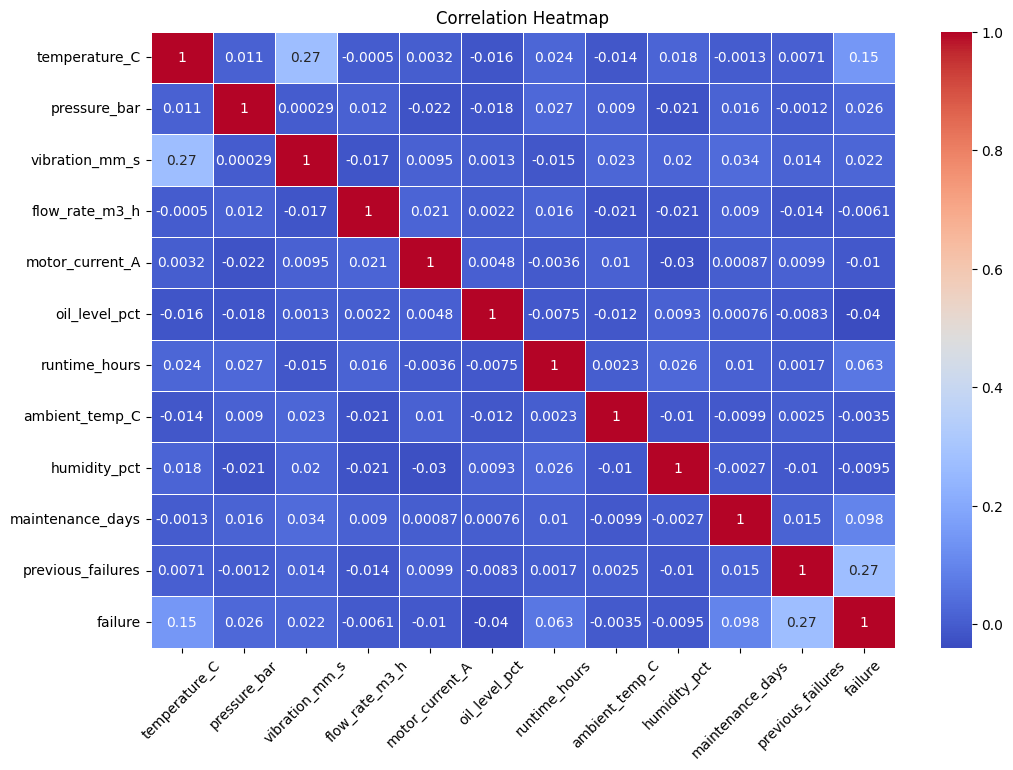

In [207]:
# correlation heatmap

correlation = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,          # Show correlation values
    cmap="coolwarm",
    linewidths=0.5
)


plt.xticks(rotation=45)
plt.title("Correlation Heatmap")
plt.show()

## Correlation Analysis - Key Observations

#### - The `previous_failures` feature shows the highest positive correlation (0.27) with the target variable, indicating that equipment with a history of failures is more likely to fail again.
#### - `temperature_C` has a positive correlation (0.15), suggesting that higher operating temperatures may increase the likelihood of equipment failure.
#### - `maintenance_days` and `runtime_hours` show weak positive correlations, indicating a slight increase in failure risk as maintenance becomes less recent and operating hours increase.
#### - `oil_level_pct` has a weak negative correlation (-0.04), implying that higher oil levels may slightly reduce the probability of equipment failure.
#### - Overall, no feature exhibits a very strong linear correlation with the target variable, which is common in real-world predictive maintenance datasets. Machine learning models such as Random Forest and XGBoost can still capture complex, non-linear relationships among multiple features.

In [208]:
# target corelation

correlation["failure"].sort_values(ascending=False)

failure              1.000000
previous_failures    0.270029
temperature_C        0.149841
maintenance_days     0.097695
runtime_hours        0.062888
pressure_bar         0.026356
vibration_mm_s       0.022297
ambient_temp_C      -0.003457
flow_rate_m3_h      -0.006087
humidity_pct        -0.009499
motor_current_A     -0.010185
oil_level_pct       -0.039943
Name: failure, dtype: float64

### Observation

#### This analysis identifies which sensor variables have the strongest positive or negative correlation with equipment failure.

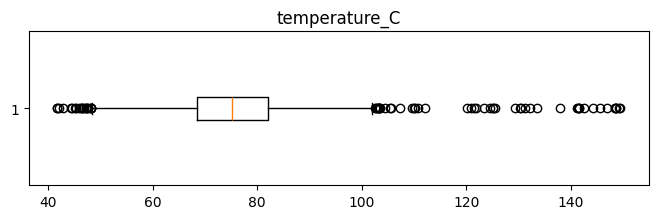

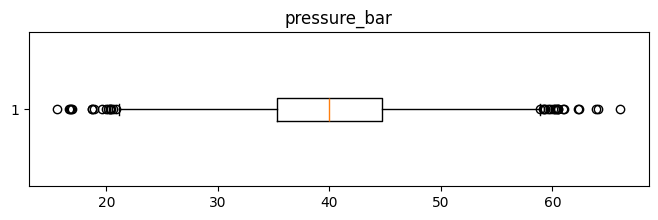

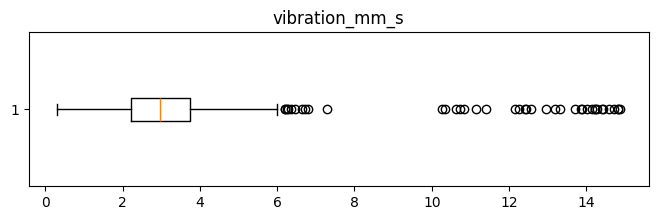

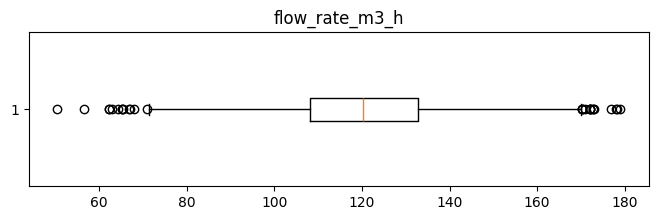

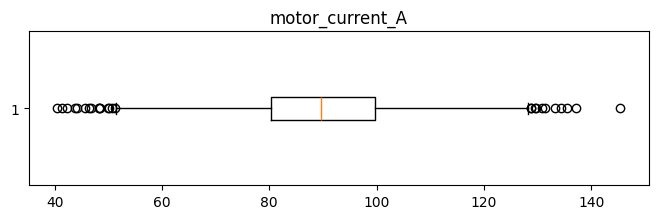

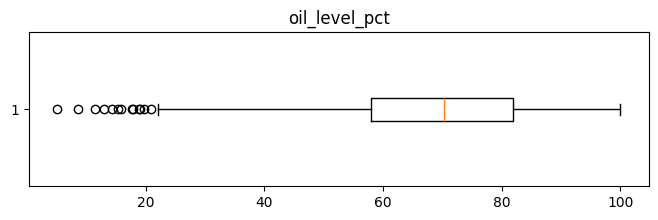

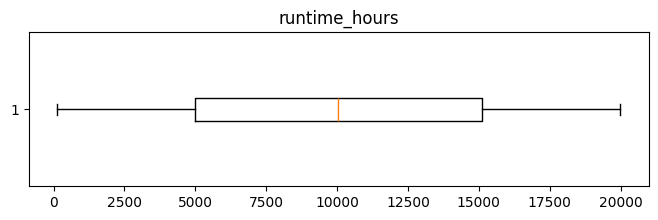

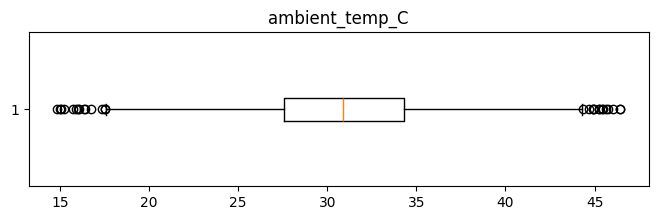

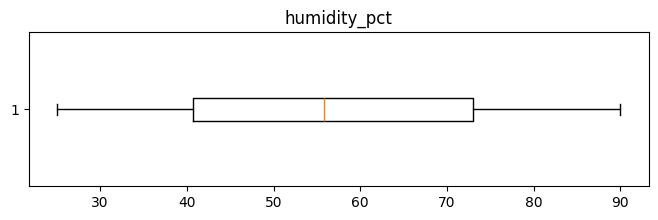

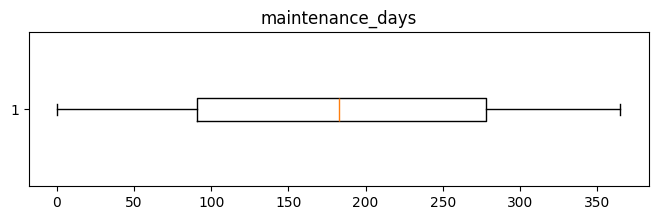

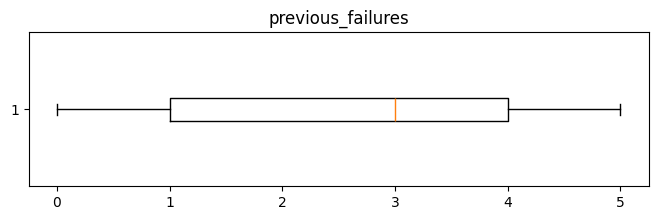

In [210]:
# plotting boxplots for outlier detection

numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns.drop("failure")

for column in numerical_columns:

    plt.figure(figsize=(8,2))

    plt.boxplot(df[column].dropna(),
                vert=False)

    plt.title(column)

    plt.show()

### Outlier Detection

#### Boxplots are used to identify potential outliers in numerical features. Outliers can significantly influence machine learning models and may require treatment during feature engineering.

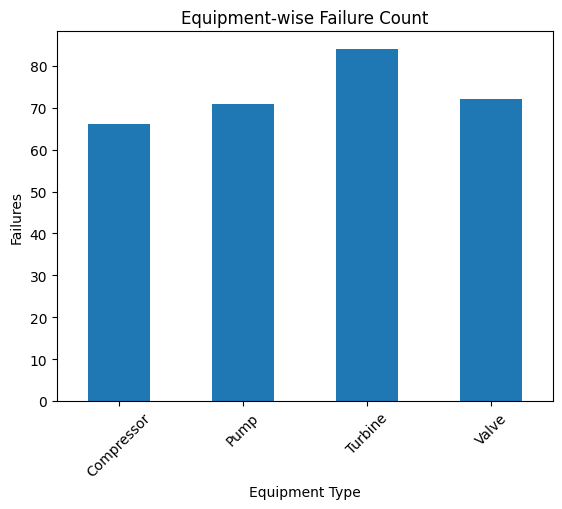

In [211]:
# equipment wise failure analysis

equipment_failure = df.groupby("equipment_type")["failure"].sum()

equipment_failure.plot(kind="bar")

plt.title("Equipment-wise Failure Count")

plt.xlabel("Equipment Type")

plt.ylabel("Failures")

plt.xticks(rotation=45)

plt.show()

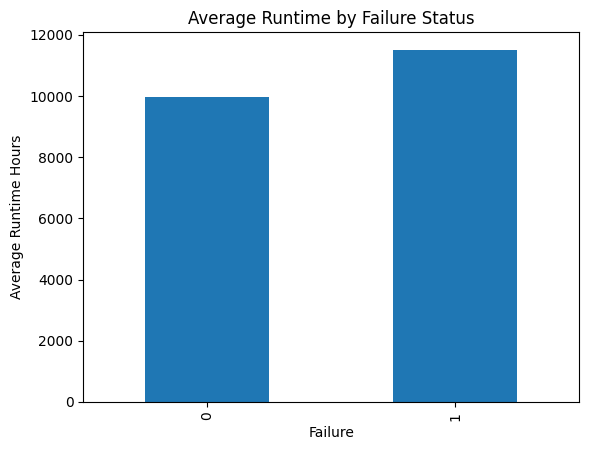

In [212]:
# runtime vs failure

df.groupby("failure")["runtime_hours"].mean().plot(kind="bar")

plt.title("Average Runtime by Failure Status")
plt.xlabel("Failure")
plt.ylabel("Average Runtime Hours")
plt.show()

### Runtime vs Failure Analysis

#### This analysis compares the average runtime of equipment that experienced failure with equipment that operated normally. The objective is to determine whether longer operating hours are associated with a higher likelihood of equipment failure. Such insights can help optimize maintenance schedules and reduce unexpected downtime.

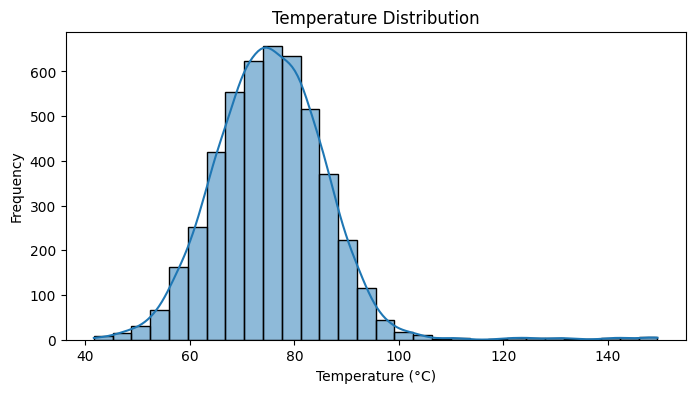

In [213]:
# temperature distribution

plt.figure(figsize=(8,4))

sns.histplot(df["temperature_C"].dropna(), kde=True,bins=30)

plt.title("Temperature Distribution")

plt.xlabel("Temperature (°C)")

plt.ylabel("Frequency")

plt.show()

### Observation

#### The histogram shows the distribution of equipment temperature values. Most observations are concentrated within the normal operating temperature range, while a few unusually high values indicate the presence of potential outliers. Understanding this distribution helps assess data quality and identify whether temperature could be an important feature for predicting equipment failures.

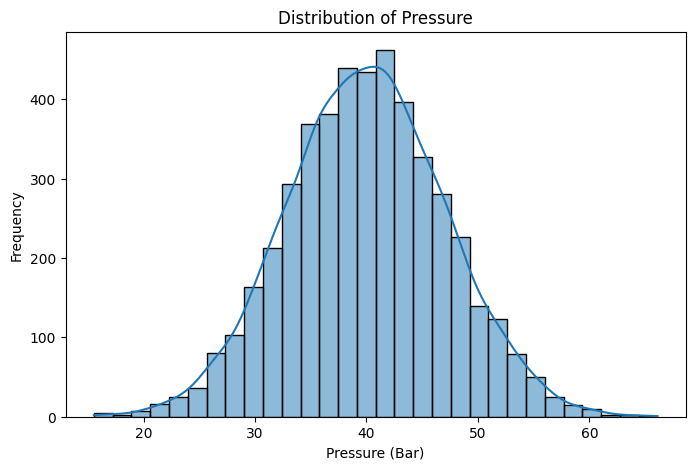

In [214]:
# pressure distribution

plt.figure(figsize=(8,5))

sns.histplot(df["pressure_bar"].dropna(), kde=True,bins=30, edgecolor="black")

plt.title("Distribution of Pressure")
plt.xlabel("Pressure (Bar)")
plt.ylabel("Frequency")

plt.show()

### Observation

#### The pressure values are concentrated within a typical operating range, with only a few observations at the extreme ends. This suggests that most equipment operates under stable pressure conditions, while a small number of records may represent abnormal operating states.

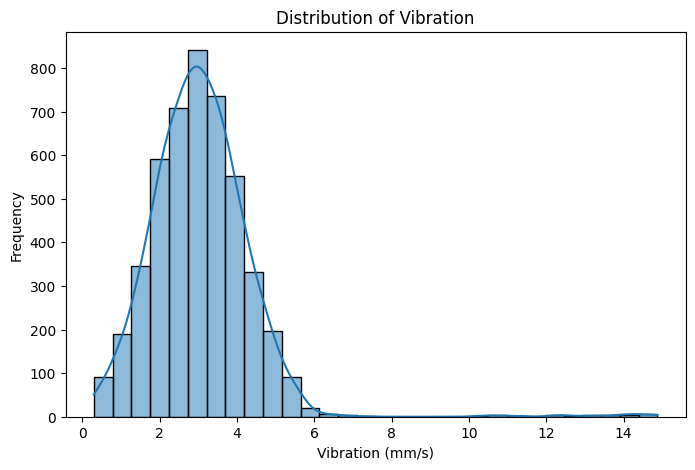

In [215]:
# vibration distribution

plt.figure(figsize=(8,5))

sns.histplot(df["vibration_mm_s"].dropna(),  kde=True, bins=30, edgecolor="black")

plt.title("Distribution of Vibration")
plt.xlabel("Vibration (mm/s)")
plt.ylabel("Frequency")

plt.show()

### Observation

#### Most vibration readings fall within the normal operating range, while a few higher values indicate potential abnormal machine behavior. Elevated vibration levels may signal mechanical issues such as bearing wear or shaft misalignment, making this feature valuable for predictive maintenance.

In [216]:
# now handling missing values with median 

df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())
df

,timestamp,equipment_id,equipment_type,temperature_C,pressure_bar,vibration_mm_s,flow_rate_m3_h,motor_current_A,oil_level_pct,runtime_hours,ambient_temp_C,humidity_pct,maintenance_days,previous_failures,failure
0,2026-01-01T00:00:00,EQ-1013,Compressor,72.30,35.99,0.34,101.47,81.06,51.1,469,23.74,50.00,130.0,0,0
1,2026-01-01T01:00:00,EQ-1041,Turbine,83.42,42.76,4.34,115.42,73.35,60.5,14489,32.62,34.70,113.0,4,0
2,2026-01-01T02:00:00,EQ-1042,Turbine,67.78,31.36,3.15,114.99,105.03,59.3,8707,29.54,84.00,46.0,1,0
3,2026-01-01T03:00:00,EQ-1044,Pump,79.91,43.29,2.60,108.37,76.36,70.2,2490,39.49,85.40,358.0,5,1
4,2026-01-01T04:00:00,EQ-1026,Turbine,66.82,28.97,2.81,116.51,115.56,72.7,12814,27.28,85.20,23.0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5020,2026-06-16T11:00:00,EQ-1030,Pump,81.24,43.81,3.99,92.20,91.26,87.6,4280,28.97,39.50,187.0,4,0
5021,2026-07-23T00:00:00,EQ-1048,Turbine,73.51,43.52,2.47,127.00,71.04,75.9,7019,27.85,55.85,266.0,1,0
5022,2026-07-06T21:00:00,EQ-1021,Pump,59.71,44.38,2.71,124.94,109.43,75.9,10633,35.15,36.90,198.0,4,0
5023,2026-01-31T15:00:00,EQ-1029,Pump,70.13,37.95,3.40,116.21,85.43,92.4,18010,30.86,82.40,139.0,4,0


In [217]:
# verify the missing values

df.isnull().sum()

timestamp            0
equipment_id         0
equipment_type       0
temperature_C        0
pressure_bar         0
vibration_mm_s       0
flow_rate_m3_h       0
motor_current_A      0
oil_level_pct        0
runtime_hours        0
ambient_temp_C       0
humidity_pct         0
maintenance_days     0
previous_failures    0
failure              0
dtype: int64

In [218]:
# handling outliers

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[column] = df[column].clip(lower, upper)
    df

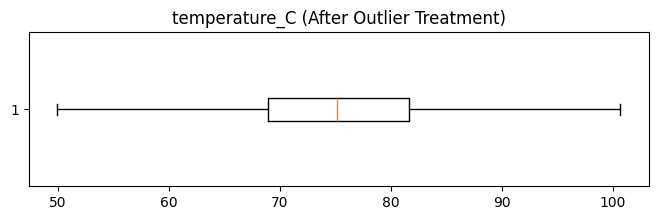

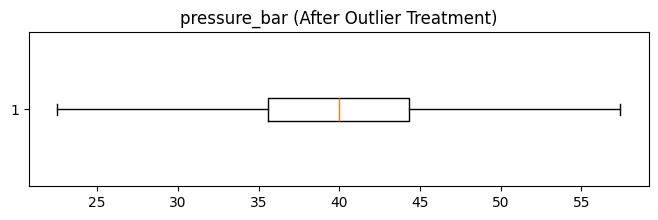

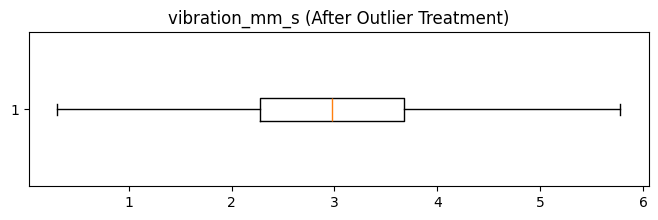

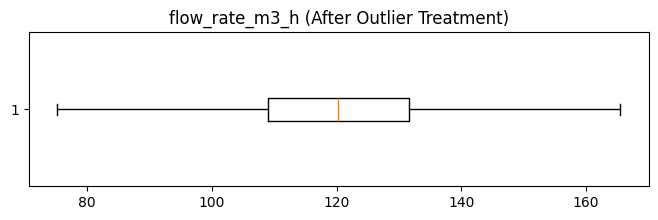

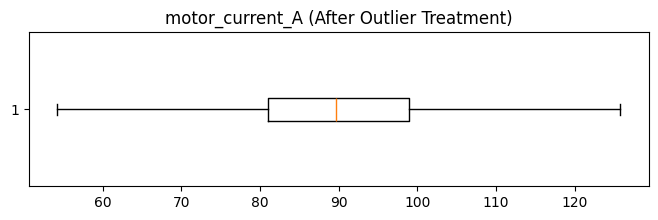

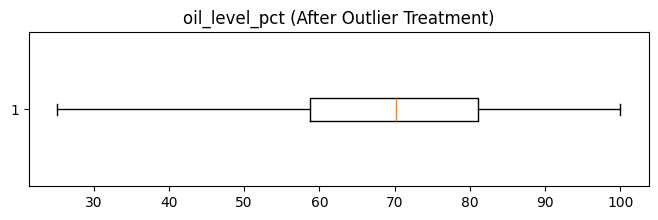

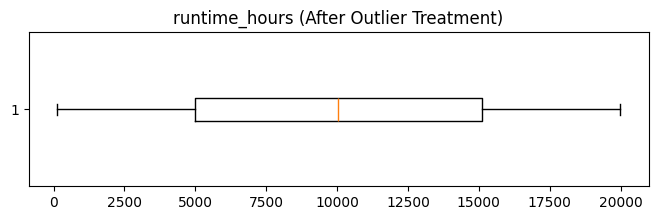

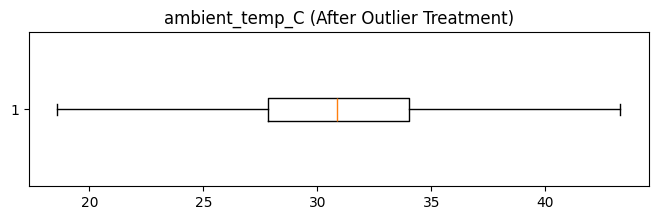

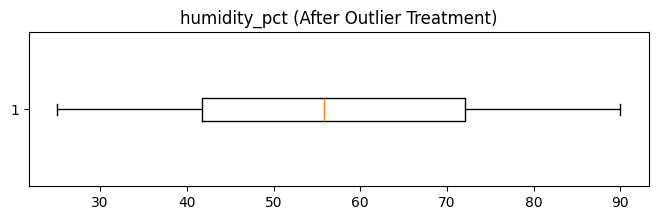

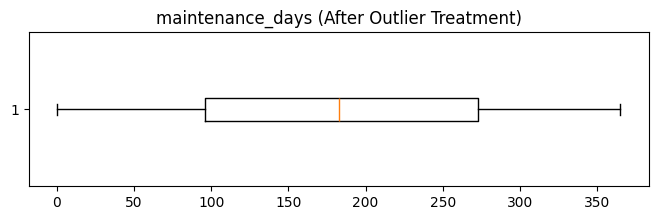

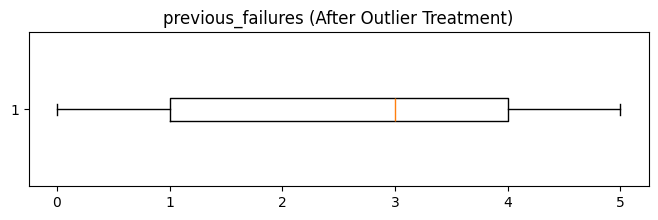

In [219]:
# verify the outliers if present or not

for column in numerical_columns:
    plt.figure(figsize=(8,2))
    plt.boxplot(df[column], vert=False)
    plt.title(f"{column} (After Outlier Treatment)")
    plt.show()

### Observation

#### Outliers in the numerical features were treated using the IQR method. Extreme values were capped to the calculated lower and upper limits rather than removing entire records. This helps maintain the dataset size while minimizing the impact of unusually high or low sensor readings on model performance.

## ENCODING CATEGORICAL VARIABLES

#### Now, we have to drop some following irrelevant features to reduce redundancy:

##### - `timestamp` is unique for every record and is not directly useful for the model to train
##### - `equipment_id` is just an identifier and doesn't help the model learn patterns.

In [220]:
df = df.drop(columns=["timestamp", "equipment_id"])

In [221]:
## verify cateforical variables

df.columns

Index(['equipment_type', 'temperature_C', 'pressure_bar', 'vibration_mm_s',
       'flow_rate_m3_h', 'motor_current_A', 'oil_level_pct', 'runtime_hours',
       'ambient_temp_C', 'humidity_pct', 'maintenance_days',
       'previous_failures', 'failure'],
      dtype='str')

In [222]:
df = pd.get_dummies(df,columns=["equipment_type"], drop_first=True, dtype=int)

### Observation

#### One-Hot Encoding creates a separate binary column for each equipment type. The parameter `drop_first=True` was used to avoid the *Dummy Variable Trap (multicollinearity)* by removing one category and treating it as the reference category. In this dataset, *Compressor* is used as the reference category. If all dummy variables are 0, the equipment type is interpreted as *Compressor*.

In [223]:
df.head()

,temperature_C,pressure_bar,vibration_mm_s,flow_rate_m3_h,motor_current_A,oil_level_pct,runtime_hours,ambient_temp_C,humidity_pct,maintenance_days,previous_failures,failure,equipment_type_Pump,equipment_type_Turbine,equipment_type_Valve
0,72.30,35.99,0.34,101.47,81.06,51.1,469,23.74,50.0,130.0,0,0,0,0,0
1,83.42,42.76,4.34,115.42,73.35,60.5,14489,32.62,34.7,113.0,4,0,0,1,0
2,67.78,31.36,3.15,114.99,105.03,59.3,8707,29.54,84.0,46.0,1,0,0,1,0
3,79.91,43.29,2.60,108.37,76.36,70.2,2490,39.49,85.4,358.0,5,1,1,0,0
4,66.82,28.97,2.81,116.51,115.56,72.7,12814,27.28,85.2,23.0,4,0,0,1,0


## Separate Features and Target

In [224]:
X = df.drop("failure", axis=1)

y = df["failure"]

print(X.shape)
print(y.shape)

(5025, 14)
(5025,)


### Objective

#### Before training machine learning models, the dataset is divided into:

#### - **Features (X):** Independent variables used for prediction.
#### - **Target (y):** Dependent variable (`failure`) that the model aims to predict.

In [225]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (4020, 14)
X_test  : (1005, 14)
y_train : (4020,)
y_test  : (1005,)


### Objective

#### The dataset is divided into training and testing sets using an 80:20 ratio.

#### - Training Set (80%): Used to train the machine learning models.
#### - Testing Set (20%): Used to evaluate the performance of the trained models on unseen data.

In [226]:
## feature scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print(X_train_scaled.shape)
print(X_test_scaled.shape)

(4020, 14)
(1005, 14)


### Objective

#### Feature scaling standardizes numerical features by transforming them to have a mean of 0 and a standard deviation of 1.

#### Scaling is particularly important for distance-based and linear models such as Logistic Regression, while tree-based algorithms like Random Forest and XGBoost are generally unaffected by feature scaling.

## Model Building

In [227]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)


### Logistic Regression

#### - Simple
#### - Fast
#### - Easy to interpret
#### - Good baseline model

In [228]:
log_model = LogisticRegression(random_state=42,max_iter=1000)

log_model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [233]:
# prediction

y_pred_log = log_model.predict(X_test_scaled)
y_pred_log

array([0, 0, 0, ..., 0, 0, 0], shape=(1005,))

In [236]:
## evaluation metrics

accuracy = accuracy_score(y_test, y_pred_log)

precision = precision_score(y_test, y_pred_log)

recall = recall_score(y_test, y_pred_log)

f1 = f1_score(y_test, y_pred_log)

roc = roc_auc_score(y_test, y_pred_log)

print('accuracy:', accuracy)
print('precision:', precision)
print('recall:', recall)     
print('f1:', f1 )     
print('roc:', roc)

accuracy: 0.9402985074626866
precision: 0.4
recall: 0.03389830508474576
f1: 0.0625
roc: 0.5153635288637258


### Logistic Regression - Initial Results

#### Observation:

##### The baseline Logistic Regression model achieved high accuracy due to the imbalanced nature of the dataset. However, the recall and F1-score were very low, indicating that the model failed to identify most equipment failures.

##### Since predictive maintenance focuses on detecting failures before they occur, improving recall is more important than maximizing overall accuracy. Therefore, the model will be retrained using `class_weight='balanced'` to better handle class imbalance.

In [238]:
log_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

log_model.fit(X_train_scaled, y_train)

y_pred_log = log_model.predict(X_test_scaled)
y_pred_log

array([0, 0, 0, ..., 0, 1, 0], shape=(1005,))

In [240]:
accuracy = accuracy_score(y_test, y_pred_log)

precision = precision_score(y_test, y_pred_log)

recall = recall_score(y_test, y_pred_log)

f1 = f1_score(y_test, y_pred_log)

roc = roc_auc_score(y_test, y_pred_log)

print('accuracy:', accuracy)
print('precision:', precision)
print('recall:', recall)     
print('f1:', f1 ) 
print('roc:', roc)

accuracy: 0.7800995024875622
precision: 0.2
recall: 0.9152542372881356
f1: 0.3282674772036474
roc: 0.8434622137814886


## Observations:

#### Logistic Regression (Balanced)

##### - To address class imbalance, Logistic Regression was retrained using `class_weight='balanced'`.

##### - Compared with the baseline model, recall improved significantly from approximately **3%** to **91%**, indicating that the model became much more effective at identifying equipment failures.

##### - Although overall accuracy decreased, this trade-off is acceptable for predictive maintenance because detecting potential failures is more important than maximizing overall accuracy.


### Model Performance

| Metric | Value |
|--------|-------|
| Accuracy | **78%** |
| Precision | **20%** |
| Recall | **91.5%** |
| F1 Score | **33%** |
| ROC-AUC | **84.3%** |


### Random Forest Model

In [245]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_pred_rf

array([0, 0, 0, ..., 0, 0, 0], shape=(1005,))

In [246]:
accuracy_score(y_test, y_pred_rf)

precision_score(y_test, y_pred_rf)

recall_score(y_test, y_pred_rf)

f1_score(y_test, y_pred_rf)

roc_auc_score(y_test, y_pred_rf)

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97       946
           1       0.50      0.02      0.03        59

    accuracy                           0.94      1005
   macro avg       0.72      0.51      0.50      1005
weighted avg       0.92      0.94      0.91      1005



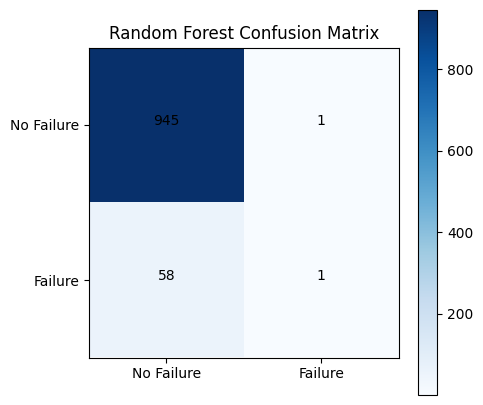

In [247]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["No Failure","Failure"])
plt.yticks([0,1],["No Failure","Failure"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha="center")

plt.show()

### Observation

#### A confusion matrix provides a detailed evaluation of a classification model by comparing the actual class labels with the predicted class labels.

#### Unlike accuracy, the confusion matrix helps identify the number of correctly and incorrectly classified equipment failures, making it especially useful for imbalanced datasets such as predictive maintenance.

#### The confusion matrix consists of four components:

### - *True Positive (TP):* Equipment failure correctly predicted as failure.
### - *True Negative (TN):* Normal equipment correctly predicted as normal.
### - *False Positive (FP):* Normal equipment incorrectly predicted as failure.
### - *False Negative (FN):* Equipment failure incorrectly predicted as normal.

#### For predictive maintenance, minimizing **False Negatives (FN)** is particularly important because undetected failures can lead to unexpected equipment breakdowns, production downtime, and increased maintenance costs.

In [251]:
# chnaging the prediction hreshold

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

y_prob = rf_model.predict_proba(X_test)[:, 1]

y_pred_rf = (y_prob >= 0.20).astype(int)
y_pred_rf 

array([0, 0, 0, ..., 0, 0, 0], shape=(1005,))

In [252]:
print(classification_report(y_test, y_pred_rf))

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.95      0.95       946
           1       0.32      0.41      0.36        59

    accuracy                           0.91      1005
   macro avg       0.64      0.68      0.65      1005
weighted avg       0.92      0.91      0.92      1005

Accuracy : 0.9134328358208955
Precision: 0.3157894736842105
Recall   : 0.4067796610169492
F1 Score : 0.35555555555555557
ROC-AUC  : 0.6759056867452611


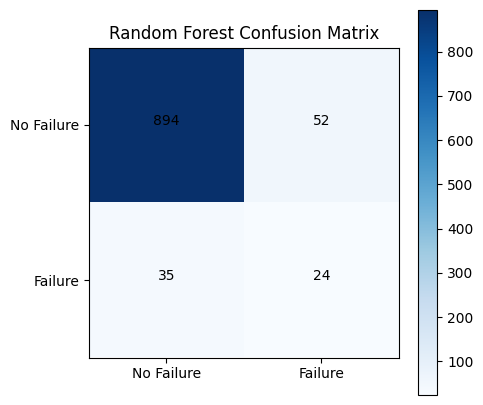

In [253]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,5))

plt.imshow(cm, cmap="Blues")

plt.title("Random Forest Confusion Matrix")

plt.colorbar()

plt.xticks([0,1],["No Failure","Failure"])
plt.yticks([0,1],["No Failure","Failure"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j,i,cm[i,j],ha="center")

plt.show()

### Observation

#### - The confusion matrix shows that the Random Forest model correctly classified most normal operating conditions while detecting a portion of actual equipment failures.

#### - Although the model achieved high overall accuracy, some failure cases were still misclassified as normal operations (False Negatives). This indicates that further optimization or alternative models such as XGBoost may improve failure detection performance.

#### - Overall, the confusion matrix highlights the trade-off between overall accuracy and the ability to correctly identify equipment failures.


### Model Performance

| Metric | Value |
|--------|-------|
| Accuracy | **91%** |
| Precision | **32%** |
| Recall | **41%** |
| F1 Score | **36%** |
| ROC-AUC | **68%** |


## XG BOOST

In [258]:
!pip install xgboost

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)
y_pred_xgb 


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


array([0, 0, 0, ..., 0, 0, 0], shape=(1005,))

In [259]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

print(classification_report(y_test, y_pred_xgb))

print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))
print("ROC-AUC  :", roc_auc_score(y_test, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.95      0.99      0.97       946
           1       0.46      0.10      0.17        59

    accuracy                           0.94      1005
   macro avg       0.70      0.55      0.57      1005
weighted avg       0.92      0.94      0.92      1005

Accuracy : 0.9402985074626866
Precision: 0.46153846153846156
Recall   : 0.1016949152542373
F1 Score : 0.16666666666666666
ROC-AUC  : 0.5471476690436091


### Objective

XGBoost (Extreme Gradient Boosting) is an advanced ensemble learning algorithm that builds multiple decision trees sequentially. It is widely used in machine learning competitions and industrial applications because of its high predictive performance and ability to handle complex datasets.

---

### Model Performance

| Metric | Value |
|--------|-------|
| Accuracy | **94.03%** |
| Precision | **46.15%** |
| Recall | **10.17%** |
| F1 Score | **16.67%** |
| ROC-AUC | **54.71%** |

---

### Observation

Although XGBoost achieved high overall accuracy and precision, it failed to detect most equipment failures due to the class imbalance present in the dataset.

The recall score was significantly lower than that of the balanced Logistic Regression model, making XGBoost unsuitable for this predictive maintenance application.

Therefore, XGBoost was not selected as the final deployment model.

## Model Comparison Table

#### - Four machine learning algorithms were trained and evaluated for predictive maintenance.

#### - The models were compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC.

#### - Since predictive maintenance focuses on identifying equipment failures before they occur, Recall and ROC-AUC were considered more important than overall Accuracy during model selection.

In [262]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Logistic Regression (Balanced)",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy":[
        0.9403,
        0.7801,
        0.9134,
        0.9403
    ],
    "Precision":[
        0.40,
        0.20,
        0.3158,
        0.4615
    ],
    "Recall":[
        0.0339,
        0.9153,
        0.4068,
        0.1017
    ],
    "F1 Score":[
        0.0625,
        0.3283,
        0.3556,
        0.1667
    ],
    "ROC-AUC":[
        0.515,
        0.84,
        0.6759,
        0.5471
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9403,0.4000,0.0339,0.0625,0.5150
1,Logistic Regression (Balanced),0.7801,0.2000,0.9153,0.3283,0.8400
2,Random Forest,0.9134,0.3158,0.4068,0.3556,0.6759
3,XGBoost,0.9403,0.4615,0.1017,0.1667,0.5471


## Final Model Selection

### ***Logistic Regression (Balanced)***: 

#### - Although Random Forest and XGBoost achieved higher overall accuracy, they failed to identify a sufficient number of equipment failures.

#### - The balanced Logistic Regression model achieved the highest Recall and ROC-AUC score, making it the most suitable model for predictive maintenance.

#### - Therefore, Logistic Regression (Balanced) was selected as the final deployment model.

## Save Model

In [264]:
import joblib

joblib.dump(log_model,"predictive_maintenance_model.pkl")

['predictive_maintenance_model.pkl']

## Save Scaler

In [265]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

### Saving the Model

#### - The trained Logistic Regression model and the StandardScaler object were saved using Joblib.

#### - Saving the model allows it to be loaded later without retraining, enabling deployment in a web application.

#### - The scaler was also saved because the deployment application must preprocess new user inputs in the same way as the training data.

# **Deployment**

In [271]:
!pip install streamlit

import streamlit as st
import pandas as pd
import joblib


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [274]:
## loading model

model = joblib.load("predictive_maintenance_model.pkl")
scaler = joblib.load("scaler.pkl")

model, scaler

(LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
 StandardScaler())

In [275]:
## Title

st.set_page_config(page_title="Predictive Maintenance System",
                   layout="centered")

st.title("Oil & Gas Predictive Maintenance")

st.write("Predict whether industrial equipment is likely to fail based on sensor readings.")

2026-07-13 17:13:47.861 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:13:47.862 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:13:47.942 
  command:

    streamlit run C:\Users\ayush\AppData\Local\Programs\Python\Python314\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-07-13 17:13:47.943 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:13:47.944 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:13:47.945 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:13:47.946 Thread 'MainThread': missing ScriptRunContext! This wa

In [276]:
import os
os.getcwd()

'C:\\Users\\ayush\\AppData\\Local\\Programs\\Python\\Python314\\Scripts'

In [278]:
df = pd.read_excel("Oil_Gas_Predictive_Maintenance.xlsx")
df

,timestamp,equipment_id,equipment_type,temperature_C,pressure_bar,vibration_mm_s,flow_rate_m3_h,motor_current_A,oil_level_pct,runtime_hours,ambient_temp_C,humidity_pct,maintenance_days,previous_failures,failure
0,2026-01-01T00:00:00,EQ-1013,Compressor,72.30,35.99,0.34,101.47,81.06,51.1,469,23.74,50.0,130.0,0,0
1,2026-01-01T01:00:00,EQ-1041,Turbine,83.42,42.76,4.34,115.42,73.35,60.5,14489,32.62,34.7,113.0,4,0
2,2026-01-01T02:00:00,EQ-1042,Turbine,67.78,31.36,3.15,114.99,105.03,59.3,8707,29.54,84.0,46.0,1,0
3,2026-01-01T03:00:00,EQ-1044,Pump,79.91,43.29,2.60,108.37,76.36,NaN,2490,39.49,85.4,358.0,5,1
4,2026-01-01T04:00:00,EQ-1026,Turbine,66.82,28.97,2.81,116.51,115.56,72.7,12814,27.28,85.2,23.0,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5020,2026-06-16T11:00:00,EQ-1030,Pump,81.24,43.81,3.99,92.20,91.26,87.6,4280,28.97,39.5,187.0,4,0
5021,2026-07-23T00:00:00,EQ-1048,Turbine,73.51,43.52,2.47,127.00,71.04,75.9,7019,27.85,NaN,266.0,1,0
5022,2026-07-06T21:00:00,EQ-1021,Pump,59.71,44.38,2.71,124.94,109.43,75.9,10633,35.15,36.9,198.0,4,0
5023,2026-01-31T15:00:00,EQ-1029,Pump,70.13,37.95,3.40,116.21,85.43,92.4,18010,NaN,82.4,139.0,4,0


In [279]:
median_values = df.drop(columns="failure").median(numeric_only=True)
median_values 

temperature_C           75.19
pressure_bar            39.99
vibration_mm_s           2.98
flow_rate_m3_h         120.23
motor_current_A         89.67
oil_level_pct           70.20
runtime_hours        10040.00
ambient_temp_C          30.86
humidity_pct            55.85
maintenance_days       183.00
previous_failures        3.00
dtype: float64

In [281]:
temperature = st.number_input(
    "Temperature (°C)",
    value=float(median_values["temperature_C"])
)

pressure = st.number_input(
    "Pressure (bar)",
    value=float(median_values["pressure_bar"])
)

vibration = st.number_input(
    "Vibration (mm/s)",
    value=float(median_values["vibration_mm_s"])
)

flow_rate = st.number_input(
    "Flow Rate (m³/h)",
    value=float(median_values["flow_rate_m3_h"])
)

motor_current = st.number_input(
    "Motor Current (A)",
    value=float(median_values["motor_current_A"])
)

oil_level = st.number_input(
    "Oil Level (%)",
    value=float(median_values["oil_level_pct"])
)

runtime = st.number_input(
    "Runtime Hours",
    value=int(median_values["runtime_hours"])
)

ambient_temp = st.number_input(
    "Ambient Temperature (°C)",
    value=float(median_values["ambient_temp_C"])
)

humidity = st.number_input(
    "Humidity (%)",
    value=float(median_values["humidity_pct"])
)

maintenance_days = st.number_input(
    "Days Since Maintenance",
    value=float(median_values["maintenance_days"])
)

previous_failures = st.number_input(
    "Previous Failures",
    value=int(median_values["previous_failures"])
)

temperature, pressure, vibration , flow_rate, motor_current, oil_level, runtime, ambient_temp, humidity, maintenance_days,previous_failures

2026-07-13 17:36:42.915 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:36:42.917 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:36:42.918 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:36:42.919 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:36:42.920 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:36:42.920 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:36:42.921 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-13 17:36:42.922 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

(75.19,
 39.99,
 2.98,
 120.23,
 89.67,
 70.2,
 10040,
 30.86,
 55.849999999999994,
 183.0,
 3)

## User Input

#### Enter the latest equipment sensor readings below to predict whether the equipment is likely to fail.